在此,我要构建两个神经网络,把宏观模型预测的值作为新的输入,与涨幅因素连接起来.看看是否能起到更好的效果.

实现 **先预测,再修正** 

| 方法 | 思路 | 与你的想法的关系 |
|---|---|---|
| 堆叠泛化，Stacking | 把第一层预测作为第二层的输入，由第二层输出最终预测 | 对应“预测的价值作为新输入” |
| 残差修正，Residual correction | 第一层先预测，第二层预测第一层会错多少，最后相加 | 对应“预测＋修正” |

| 组别 | 设计 | 要回答的问题 |
|---|---|---|
| A | 原7变量基础模型 | 原模型水平是多少？ |
| B | 7变量＋4个涨幅，一层模型 | 直接加涨幅是否已经足够？ |
| C | 第一层预测＋简单线性校准，不含涨幅 | 改善是否只是纠正整体偏高、偏低？ |
| D | 第一层＋涨幅残差修正，不含交互项 | 涨幅能否解释剩余误差？ |
| E | D加入“基础预测×涨幅”交互项 | 涨幅的作用是否取决于基础预测水平？ |
| F | 第一层＋小型神经网络修正 | 更复杂的非线性是否带来额外收益？ |

# 两阶段堆叠模型与单阶段基准：2020年测试，三个种子

本节是实际执行方案；上方其他模型组合保留为历史设想，本次只比较两组。

- **Base**：原7个宏观/价格变量 → 16 → ReLU → 32 → ReLU → 预测股价。
- **Stacking**：冻结上述Base，将其预测股价与金、铜各3个涨幅合并 → 16 → ReLU → 32 → ReLU → 最终股价。第二阶段直接预测股价，不是预测残差。
- 金、铜分别构造 `P(t)/P(t-1)-1`、`P(t)/MA5(t)-1`、`P(t)/MA20(t)-1`，滚动均值包含当日。日指原数据相邻记录，窗口为5/20条记录。
- **按用户要求不用折外预测**：第二阶段用第一阶段对同一训练集的样本内预测，充分利用可用训练数据；第一阶段冻结，两个阶段各训练100轮。
- 训练集为2020年以前，测试集仅2020年。共同剔除涨幅窗口不足或缺失的记录，两个阶段和基准使用相同有效日期。2021年以后不参与本次实验。
- 种子42、7、123；ReLU、Adam、学习率0.01、全批量、标准化目标MSE训练，按原股价尺度计算MAPE（百分数，越低越好）。所有标准化器仅拟合训练集。
- “单阶段”基准本身也有16和32两个隐藏层。堆叠第一阶段直接复用对应种子的基准，保证比较一致。

沿用原数据**同日股价**目标：这不是次日预测。样本内堆叠可能使训练误差偏乐观，结论以2020年测试误差为准，不使用测试集选择轮数或种子。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_OUT', str(ROOT/'results/mlp_stacking_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123]; EPOCHS=100; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2035,2012-06-05,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
history=[]
def fit_model(X,Y,seed,label):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train(); opt.zero_grad()
        loss=((model(xt)-yt)**2).mean(); assert torch.isfinite(loss)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(): mse=((model(xt)-yt)**2).mean().item()
        history.append(dict(Seed=seed,Stage=label,Epoch=epoch,Train_MSE=mse))
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle
    model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel(); assert np.isfinite(p).all()
    return p

def save_model(bundle,seed,label,features):
    model,sx,sy=bundle
    torch.save(dict(state_dict=model.state_dict(),features=features,seed=seed,epochs=EPOCHS,
                    sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),
                    sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist(),
                    train_start=str(tr.min()),train_end=str(tr.max())),OUT/f'{label}_seed{seed}.pt')

rows=[]; frames=[]
for seed in SEEDS:
    base=fit_model(x.loc[tr,BASE],y.loc[tr],seed,'Base')
    bp=pd.Series(predict(base,x[BASE]),index=x.index)
    # 用户指定：全训练集样本内预测；不做折外划分、不反向更新第一阶段。
    meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
    stack=fit_model(meta.loc[tr],y.loc[tr],seed,'Stage2')
    sp=pd.Series(predict(stack,meta),index=x.index)
    save_model(base,seed,'Base',BASE); save_model(stack,seed,'Stage2',list(meta.columns))
    meta.to_csv(OUT/f'stage2_inputs_seed{seed}.csv',index_label='Date')
    for model,pred in [('Base',bp),('Stacking',sp)]:
        for split,idx in [('Train',tr),('Test',te)]:
            actual=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy()
            ape=100*np.abs(p-actual)/np.abs(actual)
            rows.append(dict(Seed=seed,Model=model,Split=split,N=len(idx),MAPE=ape.mean()))
            frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Model=model,Split=split,Actual=actual,Predicted=p,APE=ape)))
    print(f'Seed {seed}: two stages completed, each {EPOCHS} epochs')
metrics=pd.DataFrame(rows); predictions=pd.concat(frames,ignore_index=True)
history=pd.DataFrame(history)
metrics.to_csv(OUT/'metrics.csv',index=False)
predictions.to_csv(OUT/'predictions.csv',index=False)
history.to_csv(OUT/'training_history.csv',index=False)
test=metrics[metrics.Split=='Test']
comparison=test.pivot(index='Seed',columns='Model',values='MAPE').reindex(SEEDS)
comparison['Stacking_minus_Base_pp']=comparison.Stacking-comparison.Base
summary=test.groupby('Model').MAPE.agg(['mean','std','min','max']).reindex(['Base','Stacking'])
comparison.to_csv(OUT/'seed_comparison.csv'); summary.to_csv(OUT/'summary.csv')
assert len(metrics)==12 and len(history)==3*2*100
assert predictions.groupby(['Seed','Model','Split']).size().nunique()==2
print('2020 Test MAPE (%); negative paired difference means stacking improves')
display(comparison.round(4)); display(summary.round(4))
print('Train MAPE (%), based on in-sample predictions:')
display(metrics[metrics.Split=='Train'].pivot(index='Seed',columns='Model',values='MAPE').reindex(SEEDS).round(4))


Model,Base,Stacking,Stacking_minus_Base_pp
Seed,,,
42,12.7949,12.9362,0.1412
7,10.5378,10.4800,-0.0578
123,16.1385,15.9172,-0.2213


,mean,std,min,max
Model,,,,
Base,13.1571,2.8179,10.5378,16.1385
Stacking,13.1111,2.7228,10.4800,15.9172


Model,Base,Stacking
Seed,,
42,2.7657,2.7997
7,2.9166,2.7380
123,2.8893,2.7271


Seed 42: two stages completed, each 100 epochs
Seed 7: two stages completed, each 100 epochs
Seed 123: two stages completed, each 100 epochs
2020 Test MAPE (%); negative paired difference means stacking improves
Train MAPE (%), based on in-sample predictions:


## 预测曲线与训练过程

每个种子单独画出2020年预测；汇总值是三个种子的MAPE均值与样本标准差，并非先平均预测再算MAPE。配对差为堆叠MAPE减基准MAPE，负数表示堆叠改善。

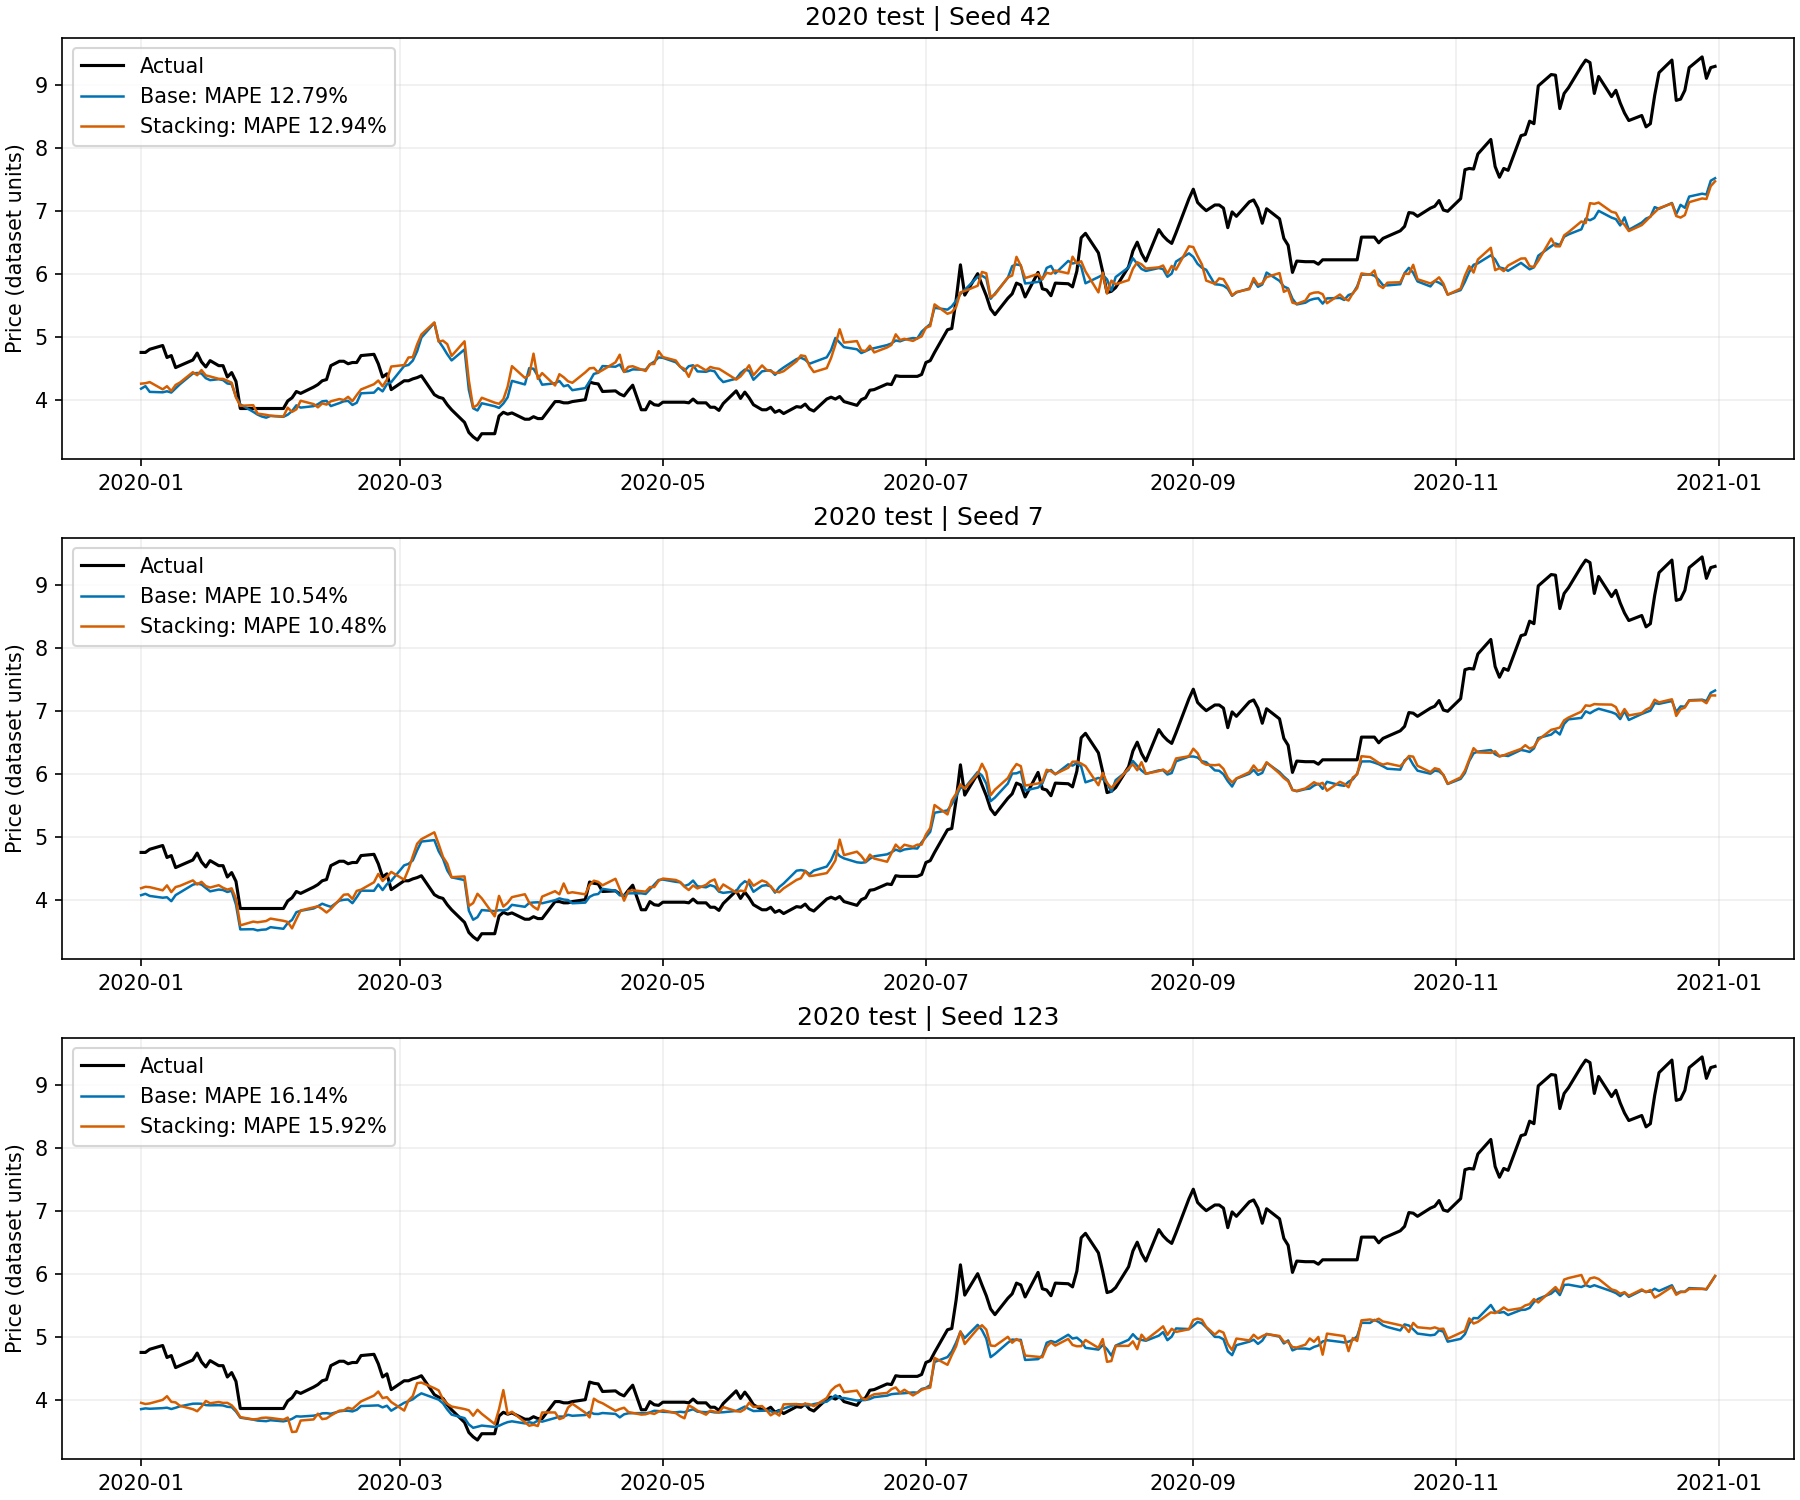

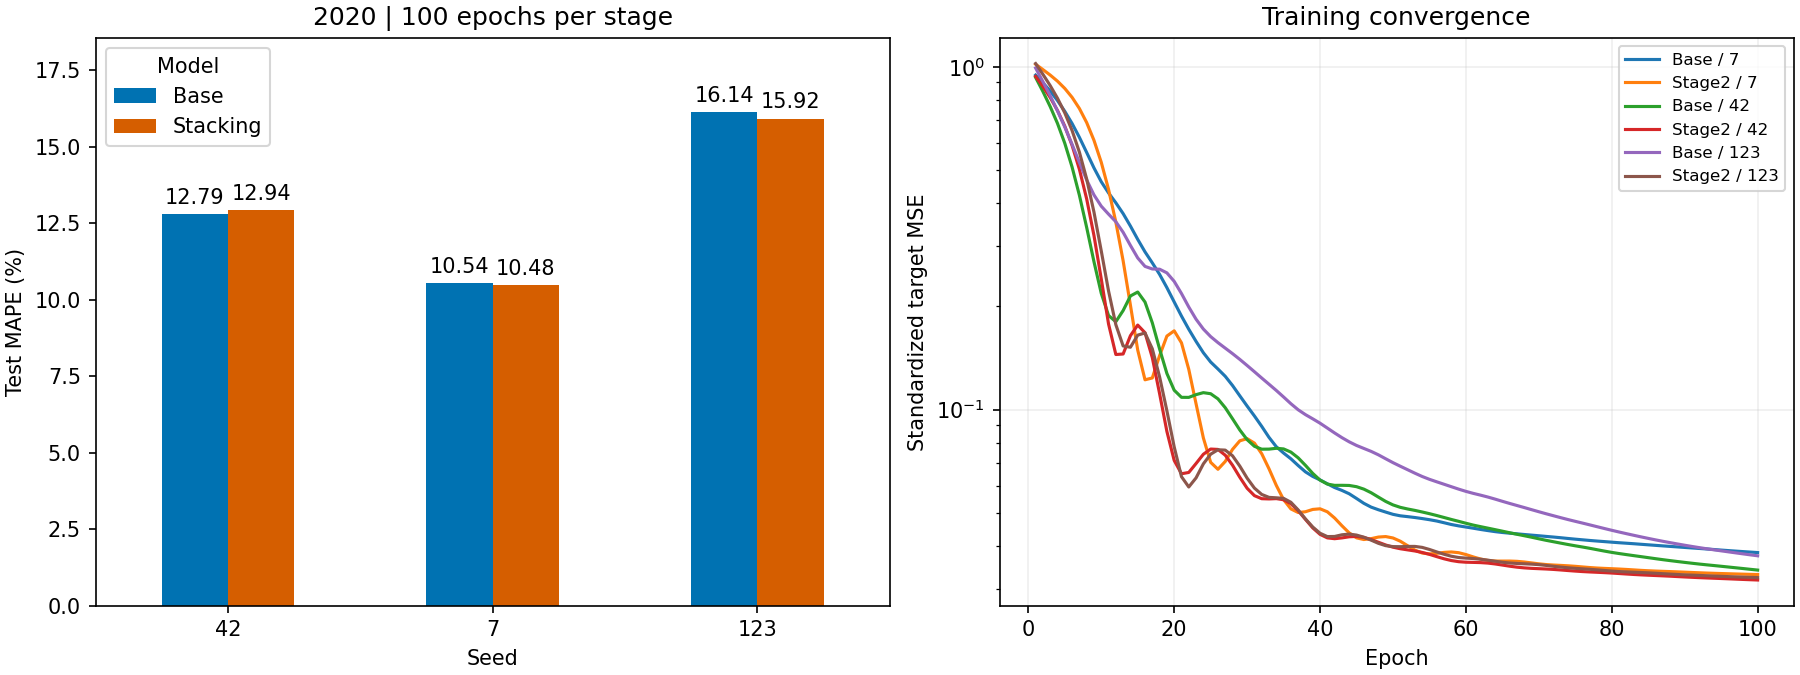

堆叠模型在2/3个种子中测试MAPE更低；平均配对差为-0.0459个百分点。
单个测试年、三个种子只能说明本次设定下的结果，不能据此证明其他年份也更好。


In [3]:
fig,axes=plt.subplots(3,1,figsize=(12,10),constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    ax.plot(te,y.loc[te],color='black',lw=1.5,label='Actual')
    for name,color in [('Base','#0072B2'),('Stacking','#D55E00')]:
        g=predictions[(predictions.Seed==seed)&(predictions.Model==name)&(predictions.Split=='Test')]
        ax.plot(g.Date,g.Predicted,color=color,lw=1.2,label=f'{name}: MAPE {comparison.loc[seed,name]:.2f}%')
    ax.set(title=f'2020 test | Seed {seed}',ylabel='Price (dataset units)'); ax.legend(); ax.grid(alpha=.2)
fig.savefig(OUT/'predictions_2020.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'predictions_2020.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
comparison[['Base','Stacking']].plot.bar(ax=axes[0],rot=0,color=['#0072B2','#D55E00'])
axes[0].set(ylabel='Test MAPE (%)',title='2020 | 100 epochs per stage')
for c in axes[0].containers: axes[0].bar_label(c,fmt='%.2f',padding=3)
axes[0].margins(y=.15)
for (seed,stage),g in history.groupby(['Seed','Stage']):
    axes[1].plot(g.Epoch,g.Train_MSE,label=f'{stage} / {seed}')
axes[1].set(xlabel='Epoch',ylabel='Standardized target MSE',yscale='log',title='Training convergence')
axes[1].legend(fontsize=8); axes[1].grid(alpha=.2)
fig.savefig(OUT/'comparison.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'comparison.png')))
monthly=predictions[predictions.Split=='Test'].copy()
monthly['Month']=monthly.Date.dt.strftime('%Y-%m')
monthly=monthly.groupby(['Month','Seed','Model']).APE.mean().unstack('Model')
monthly.to_csv(OUT/'monthly_mape.csv')
mean_delta=comparison.Stacking_minus_Base_pp.mean()
wins=int((comparison.Stacking_minus_Base_pp<0).sum())
print(f'堆叠模型在{wins}/3个种子中测试MAPE更低；平均配对差为{mean_delta:+.4f}个百分点。')
print('单个测试年、三个种子只能说明本次设定下的结果，不能据此证明其他年份也更好。')


## 本次运行结果

| 随机种子 | 基准MAPE (%) | 堆叠MAPE (%) | 堆叠−基准（百分点） |
|---|---:|---:|---:|
|42|12.7949|12.9362|+0.1412|
|7|10.5378|10.4800|−0.0578|
|123|16.1385|15.9172|−0.2213|
|均值|13.1571|13.1111|−0.0459|

三个种子的样本标准差：基准2.8179、堆叠2.7228个百分点。堆叠在2/3个种子上改善，但平均改善仅0.0459个百分点，远小于种子之间的差异，**本次结果未显示明显、稳定的优势**。

训练样本2035条（2012-06-05至2019-12-31），测试样本271条（2020-01-01至2020-12-31）。样本沿用原Dataset的日期对齐，不能把271条直接称为271个A股交易日。没有折外预测，所有有效训练样本都用于两个阶段。


# 堆叠模型训练轮数对比：100 / 200 / 400 / 800

保持前一实验的训练/测试日期、原7个基准输入、金铜6项涨幅、16×32隐藏层、ReLU、Adam学习率0.01、全批量、种子42/7/123不变。**不用折外预测**，第二阶段使用第一阶段对全部有效训练样本的样本内预测。

每组轮数E表示：**第一阶段训练E轮，冻结后生成预测，第二阶段从相同种子的初始状态训练E轮**。第一阶段在同一800轮训练路径上保存四个检查点；不同E的第二阶段因输入预测不同，独立初始化训练。每组总计2E轮，不是两个阶段合计E轮。

2020年为固定测试集；报告所有预先指定轮数，不使用测试集早停或挑选种子。第一阶段基准结果也保留，便于判断第二阶段是否改善。以下单元可单独从本节起运行。


In [1]:
from pathlib import Path
import os, json, hashlib, random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP11_EPOCH_OUT', str(ROOT/'results/mlp_stacking_epochs_11')))
OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[42,7,123]; EPOCHS=100; LR=0.01
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
dataset=ROOT/'src/pickle/Dataset.pkl'
d=pd.read_pickle(dataset)
raw=d['X'].copy(); target=d['Y'].copy()
assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
BASE=list(raw.columns); assert len(BASE)==7
# 截止2020年，先计算纯向后窗口，再分割，测试年初可使用2019年历史。
raw=raw.loc[raw.index.year<=2020]
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy(); RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily'; x[name]=raw[col]/raw[col].shift(1)-1; RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}'
        x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1
        RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid]; y=y.loc[x.index]
tr=x.index[x.index.year<2020]; te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min() and (y>0).all()
splits=pd.DataFrame([dict(Split=s,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())) for s,idx in [('Train',tr),('Test',te)]])
splits.to_csv(OUT/'splits.csv',index=False)
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
config=dict(seeds=SEEDS,epochs_per_stage=EPOCHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',train_loss='standardized target MSE',metric='MAPE percent',test_year=2020,base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions, no OOF',ma_includes_current=True,target='same-date original price',dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(splits)
display(pd.DataFrame({'Stage2 input':config['stage2_features']}))


,Split,N,Start,End
0,Train,2035,2012-06-05,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Stage2 input
0,base_prediction
1,gold_daily
2,gold_vs_ma5
3,gold_vs_ma20
4,copper_daily
5,copper_vs_ma5
6,copper_vs_ma20


In [2]:
import copy
BUDGETS=[100,200,400,800]
config['epoch_budgets_per_stage']=BUDGETS
config.pop('epochs_per_stage',None)
config['stage1_path']='shared checkpoints within seed'
config['stage2_path']='fresh fit for each budget using corresponding stage1 predictions'
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
H=[]
def train_checkpoints(X,Y,seed,stage,budget,checkpoints):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    sx=StandardScaler().fit(X); sy=StandardScaler().fit(np.asarray(Y).reshape(-1,1))
    xt=torch.tensor(sx.transform(X),dtype=torch.float32)
    yt=torch.tensor(sy.transform(np.asarray(Y).reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR); saved={}
    for epoch in range(1,max(checkpoints)+1):
        model.train(); opt.zero_grad(); loss=((model(xt)-yt)**2).mean()
        assert torch.isfinite(loss); loss.backward(); opt.step(); model.eval()
        with torch.no_grad(): mse=((model(xt)-yt)**2).mean().item()
        H.append(dict(Seed=seed,Stage=stage,Budget=budget,Epoch=epoch,Train_MSE=mse))
        if epoch in checkpoints: saved[epoch]=(copy.deepcopy(model),sx,sy)
    return saved

def predict_e(bundle,X):
    model,sx,sy=bundle; model.eval()
    with torch.no_grad(): z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    result=sy.inverse_transform(z).ravel(); assert np.isfinite(result).all()
    return pd.Series(result,index=X.index)

def save_e(bundle,seed,stage,budget,features):
    model,sx,sy=bundle
    torch.save(dict(state_dict=model.state_dict(),features=features,seed=seed,epochs=budget,
        hidden=[16,32],sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),
        sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist(),
        train_start=str(tr.min()),train_end=str(tr.max())),OUT/f'{stage}_{budget}_seed{seed}.pt')

rows=[]; frames=[]
for seed in SEEDS:
    bases=train_checkpoints(x.loc[tr,BASE],y.loc[tr],seed,'Base',800,BUDGETS)
    for budget in BUDGETS:
        base=bases[budget]; bp=predict_e(base,x[BASE])
        meta=x[RETURNS].copy(); meta.insert(0,'base_prediction',bp)
        stack=train_checkpoints(meta.loc[tr],y.loc[tr],seed,'Stage2',budget,[budget])[budget]
        sp=predict_e(stack,meta)
        save_e(base,seed,'Base',budget,BASE); save_e(stack,seed,'Stage2',budget,list(meta.columns))
        for name,pred in [('Base',bp),('Stacking',sp)]:
            for split,idx in [('Train',tr),('Test',te)]:
                actual=y.loc[idx].to_numpy(); p=pred.loc[idx].to_numpy()
                ape=100*np.abs(p-actual)/np.abs(actual)
                rows.append(dict(Seed=seed,Epochs=budget,Model=name,Split=split,N=len(idx),MAPE=ape.mean()))
                frames.append(pd.DataFrame(dict(Date=idx,Seed=seed,Epochs=budget,Model=name,Split=split,Actual=actual,Predicted=p,APE=ape)))
        print(f'Seed {seed}, {budget} epochs per stage completed',flush=True)
metrics_e=pd.DataFrame(rows); predictions_e=pd.concat(frames,ignore_index=True); history_e=pd.DataFrame(H)
metrics_e.to_csv(OUT/'metrics.csv',index=False)
predictions_e.to_csv(OUT/'predictions.csv',index=False)
history_e.to_csv(OUT/'training_history.csv',index=False)
assert len(metrics_e)==3*4*2*2
assert history_e.groupby(['Seed','Stage','Budget']).Epoch.max().tolist().count(800)==6
# 复核100轮与此前实验完全一致（若此前结果存在）。
prior=OUT.parent/'mlp_stacking_11/predictions.csv'
if prior.exists():
    old=pd.read_csv(prior,parse_dates=['Date'])
    new=predictions_e[predictions_e.Epochs==100]
    check=old.merge(new,on=['Date','Seed','Model','Split'],suffixes=('_old','_new'),validate='one_to_one')
    assert len(check)==len(old)==len(new)
    assert np.allclose(check.Actual_old,check.Actual_new,rtol=0,atol=1e-10)
    delta=np.max(np.abs(check.Predicted_old-check.Predicted_new))
    assert delta<1e-4
    print(f'100轮复现检查通过，最大预测差={delta:.8g}')
stack_metrics=metrics_e[metrics_e.Model=='Stacking']
comparison_e=stack_metrics[stack_metrics.Split=='Test'].pivot(index='Seed',columns='Epochs',values='MAPE').reindex(SEEDS)
summary_e=stack_metrics.groupby(['Epochs','Split']).MAPE.agg(['mean','std','min','max'])
paired_e=metrics_e[metrics_e.Split=='Test'].pivot(index=['Epochs','Seed'],columns='Model',values='MAPE')
paired_e['Stacking_minus_Base_pp']=paired_e.Stacking-paired_e.Base
comparison_e.to_csv(OUT/'test_mape_by_seed.csv'); summary_e.to_csv(OUT/'summary.csv'); paired_e.to_csv(OUT/'paired_comparison.csv')
print('堆叠模型2020测试MAPE (%)：'); display(comparison_e.round(4))
print('堆叠模型训练/测试MAPE均值及样本标准差：'); display(summary_e.round(4))
print('同轮数堆叠与第一阶段基准的测试对比：'); display(paired_e.round(4))


Epochs,100,200,400,800
Seed,,,,
42,12.9362,13.3050,12.5285,17.8292
7,10.4800,9.7845,15.6741,24.8620
123,15.9172,15.8298,19.3820,25.8067


mean     std      min      max
Epochs Split                                   
100    Test   13.1111  2.7228  10.4800  15.9172
       Train   2.7549  0.0392   2.7271   2.7997
200    Test   12.9731  3.0363   9.7845  15.8298
       Train   2.2930  0.0327   2.2611   2.3264
400    Test   15.8615  3.4306  12.5285  19.3820
       Train   1.9246  0.0414   1.8857   1.9680
800    Test   22.8326  4.3588  17.8292  25.8067
       Train   1.6387  0.0521   1.6051   1.6988

Model           Base  Stacking  Stacking_minus_Base_pp
Epochs Seed                                           
100    7     10.5378   10.4800                 -0.0578
       42    12.7949   12.9362                  0.1412
       123   16.1385   15.9172                 -0.2213
200    7      9.6727    9.7845                  0.1117
       42    13.3132   13.3050                 -0.0082
       123   15.6207   15.8298                  0.2091
400    7     15.5907   15.6741                  0.0834
       42    12.5932   12.5285                 -0.0647
       123   19.2906   19.3820                  0.0914
800    7     25.0359   24.8620                 -0.1739
       42    17.6403   17.8292                  0.1889
       123   25.6648   25.8067                  0.1419

Seed 42, 100 epochs per stage completed
Seed 42, 200 epochs per stage completed
Seed 42, 400 epochs per stage completed
Seed 42, 800 epochs per stage completed
Seed 7, 100 epochs per stage completed
Seed 7, 200 epochs per stage completed
Seed 7, 400 epochs per stage completed
Seed 7, 800 epochs per stage completed
Seed 123, 100 epochs per stage completed
Seed 123, 200 epochs per stage completed
Seed 123, 400 epochs per stage completed
Seed 123, 800 epochs per stage completed
100轮复现检查通过，最大预测差=2.3800659e-07
堆叠模型2020测试MAPE (%)：
堆叠模型训练/测试MAPE均值及样本标准差：
同轮数堆叠与第一阶段基准的测试对比：


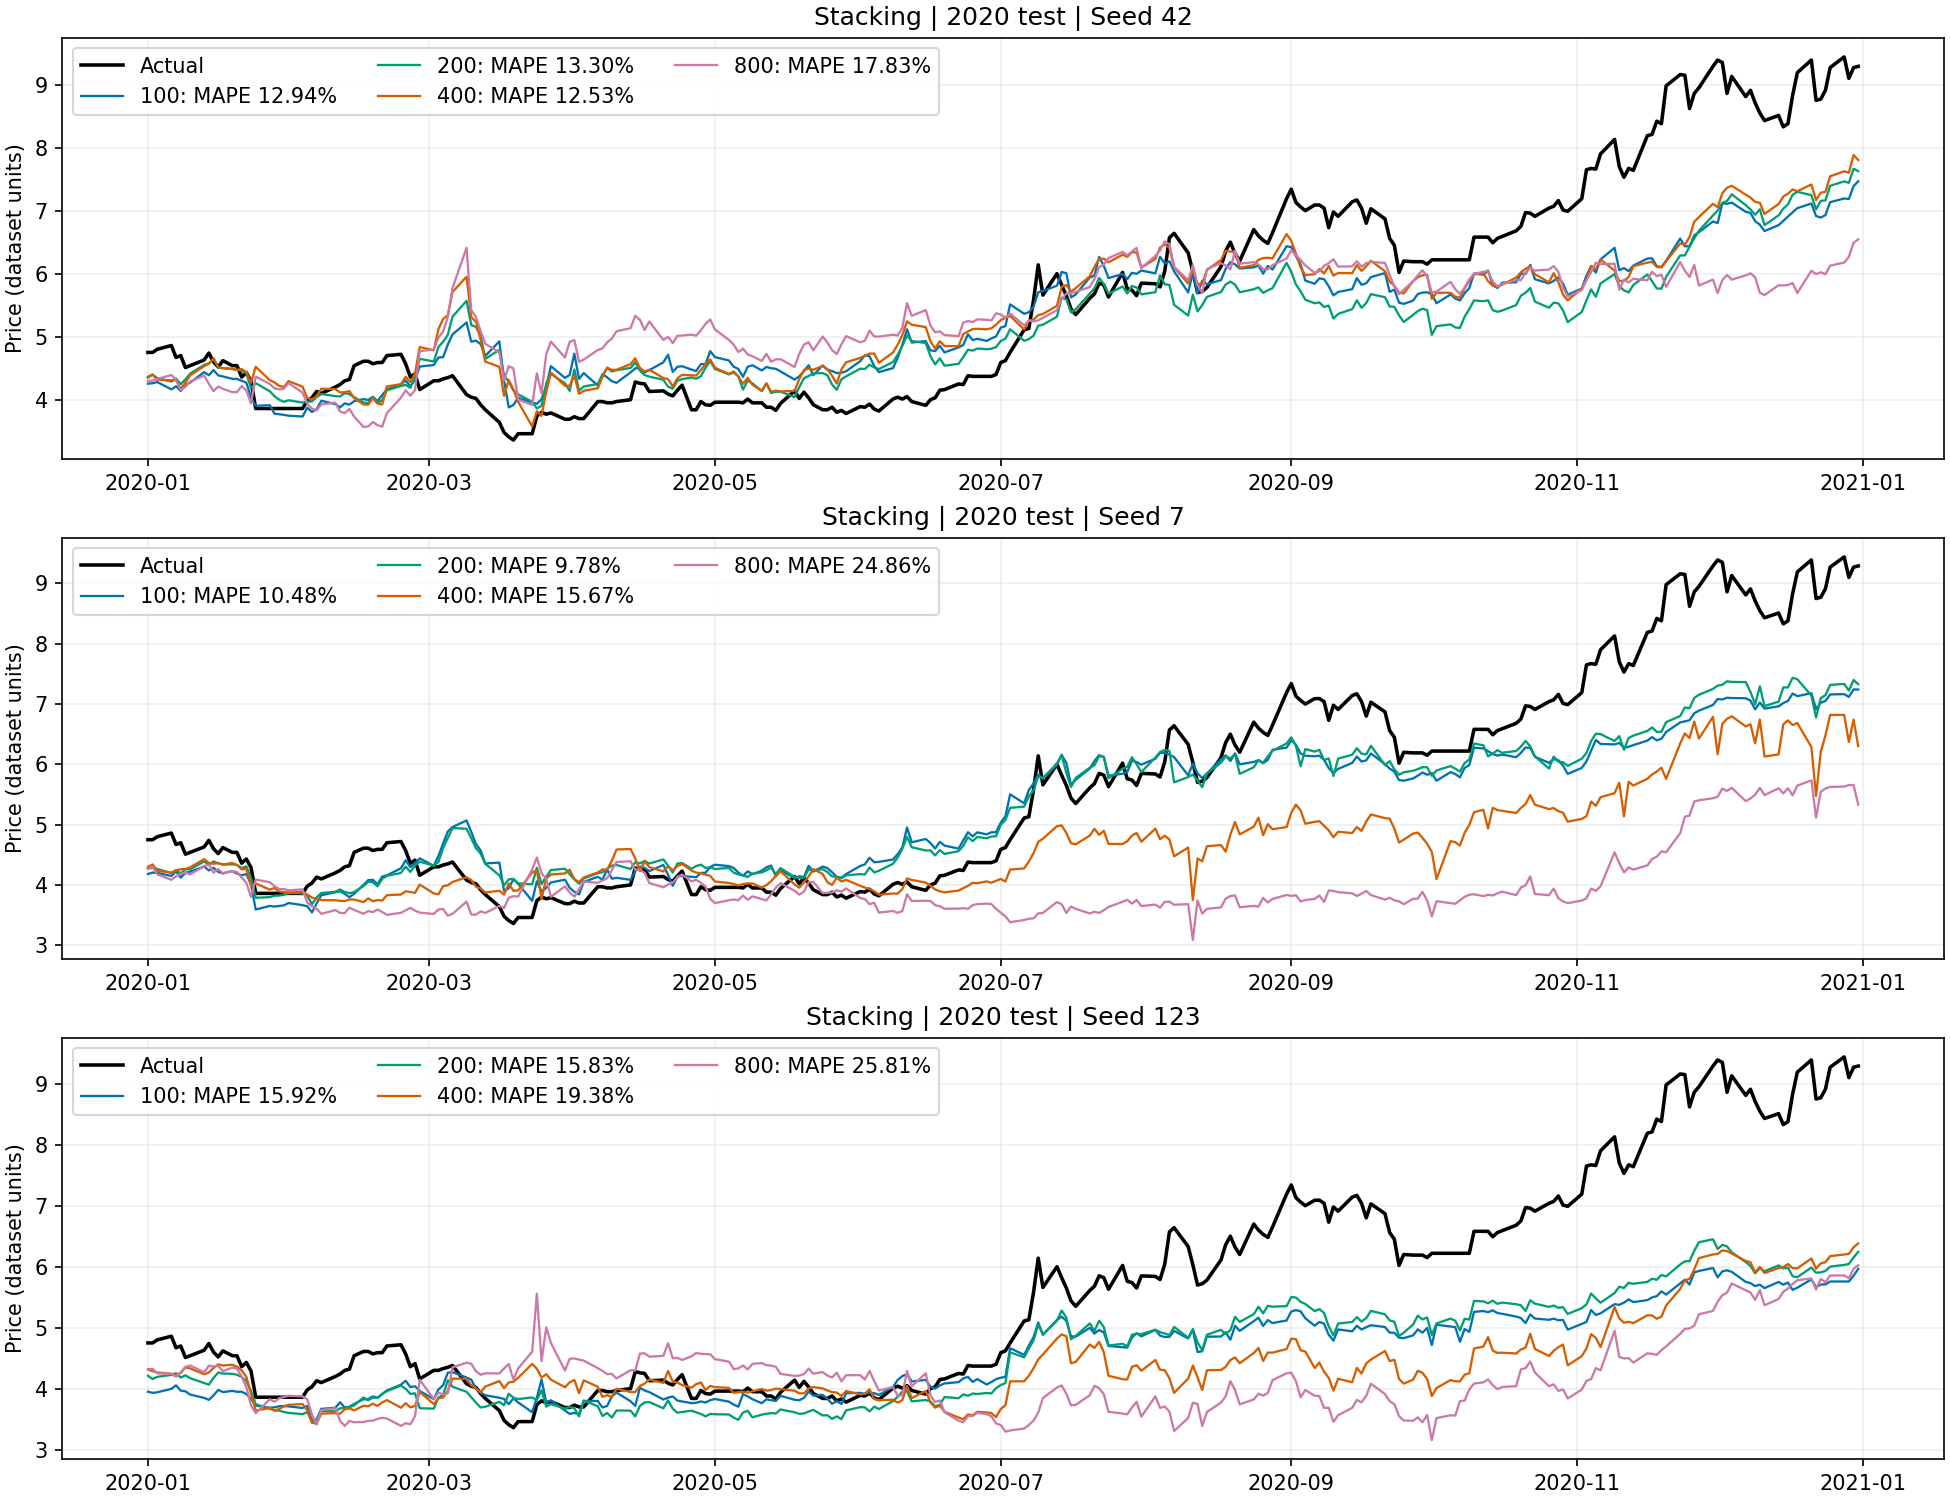

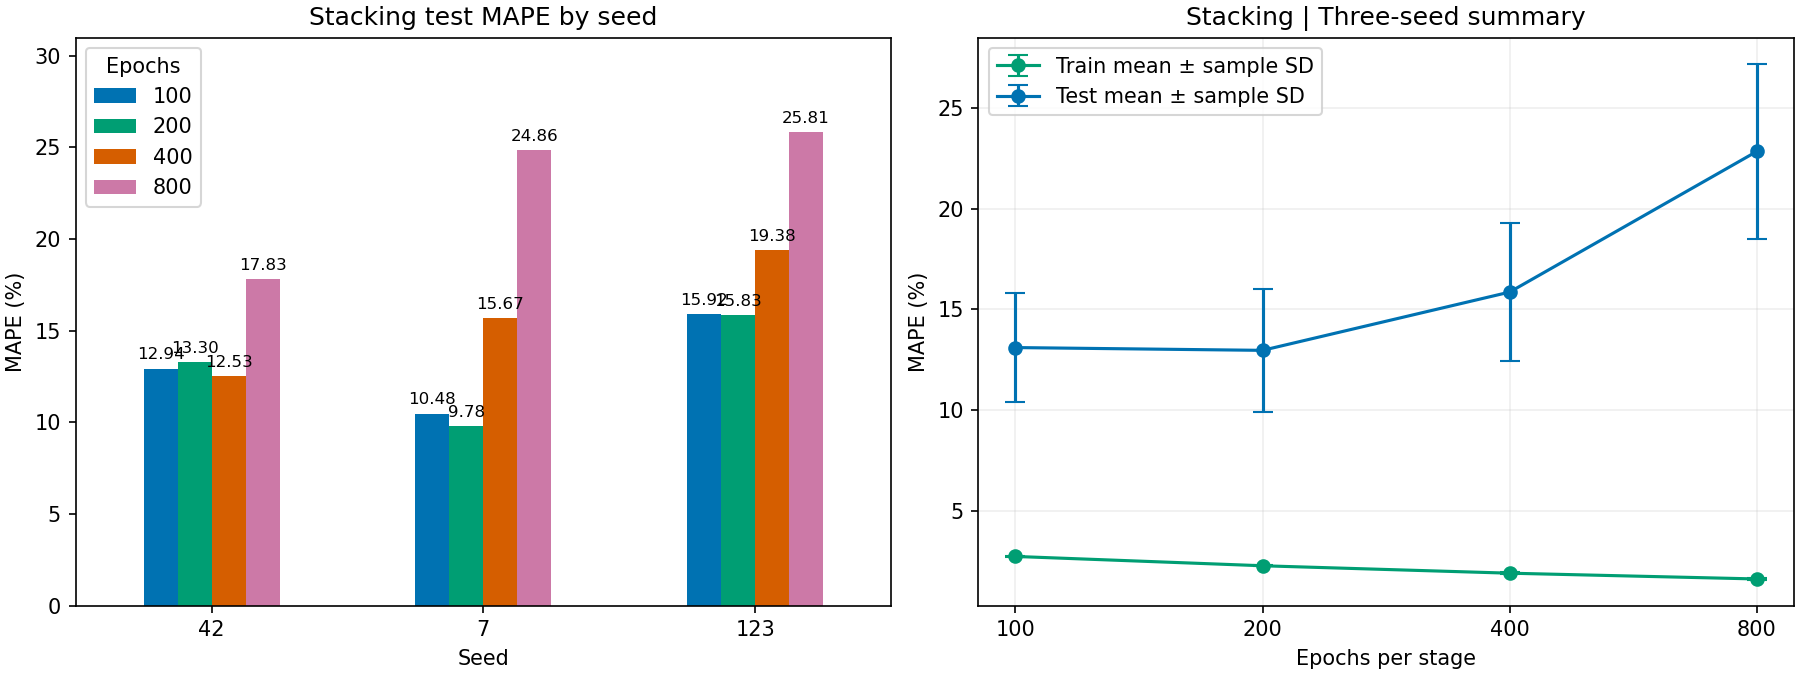

In [3]:
colors={100:'#0072B2',200:'#009E73',400:'#D55E00',800:'#CC79A7'}
fig,axes=plt.subplots(3,1,figsize=(13,10),constrained_layout=True)
for ax,seed in zip(axes,SEEDS):
    ax.plot(te,y.loc[te],color='black',lw=1.7,label='Actual')
    for budget in BUDGETS:
        g=predictions_e[(predictions_e.Seed==seed)&(predictions_e.Epochs==budget)&(predictions_e.Model=='Stacking')&(predictions_e.Split=='Test')]
        ax.plot(g.Date,g.Predicted,color=colors[budget],lw=1.1,label=f'{budget}: MAPE {comparison_e.loc[seed,budget]:.2f}%')
    ax.set(title=f'Stacking | 2020 test | Seed {seed}',ylabel='Price (dataset units)'); ax.legend(ncol=3); ax.grid(alpha=.2)
fig.savefig(OUT/'predictions_by_epochs.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'predictions_by_epochs.png')))
fig,axes=plt.subplots(1,2,figsize=(12,4.5),constrained_layout=True)
comparison_e.plot.bar(ax=axes[0],rot=0,color=[colors[e] for e in BUDGETS])
axes[0].set(title='Stacking test MAPE by seed',ylabel='MAPE (%)')
for c in axes[0].containers: axes[0].bar_label(c,fmt='%.2f',padding=3,fontsize=8)
axes[0].margins(y=.2)
for split,col in [('Train','#009E73'),('Test','#0072B2')]:
    g=summary_e.xs(split,level='Split').reindex(BUDGETS)
    axes[1].errorbar(range(4),g['mean'],yerr=g['std'],marker='o',capsize=5,color=col,label=split+' mean ± sample SD')
axes[1].set(xticks=range(4),xticklabels=BUDGETS,xlabel='Epochs per stage',ylabel='MAPE (%)',title='Stacking | Three-seed summary')
axes[1].legend(); axes[1].grid(alpha=.2)
fig.savefig(OUT/'epoch_comparison.png',dpi=150); plt.close(fig)
display(Image(filename=str(OUT/'epoch_comparison.png')))
monthly=predictions_e[predictions_e.Split=='Test'].copy()
monthly['Month']=monthly.Date.dt.strftime('%Y-%m')
monthly.groupby(['Month','Seed','Epochs','Model']).APE.mean().to_csv(OUT/'monthly_mape.csv')


## 轮数对比结论

| 每阶段轮数 | seed42测试MAPE | seed7测试MAPE | seed123测试MAPE | 测试均值 | 测试样本标准差 | 训练均值 |
|---|---:|---:|---:|---:|---:|---:|
|100|12.9362%|10.4800%|15.9172%|13.1111%|2.7228个百分点|2.7549%|
|200|13.3050%|9.7845%|15.8298%|12.9731%|3.0363个百分点|2.2930%|
|400|12.5285%|15.6741%|19.3820%|15.8615%|3.4306个百分点|1.9246%|
|800|17.8292%|24.8620%|25.8067%|22.8326%|4.3588个百分点|1.6387%|

- **200轮测试均值最低，但比100轮只低0.1381个百分点**，且seed42反而变差，不能认定200轮具有稳定优势。
- 400轮较100轮平均恶化2.7504个百分点；800轮恶化9.7215个百分点，三个种子在800轮均比100轮差。
- 训练MAPE从2.7549%持续降至1.6387%，测试误差却在400、800轮上升，呈现过拟合迹象。
- 同轮数下，堆叠与第一阶段基准的每个种子测试MAPE差距均不到0.23个百分点。第二阶段未明显纠正第一阶段的测试误差；本实验同时增加两个阶段轮数，不能单独归因于第二阶段训练过久。
- 这里的200轮最低是对2020测试结果的描述，不能代替独立验证集选参。所有预设结果均保留，没有按2020年结果重新训练。

100轮预测已复核与上一实验一致（最大绝对差小于1e-4）。本节结果保存于 `results/mlp_stacking_epochs_11`，包括各轮数模型权重、逐日预测、训练过程、按月MAPE及图表。


---

经测试,采用堆叠的方式,100与200轮对比基准的100轮都是有所改进的.